<h1><center> Macromolecular Surface concentration </center></h1>

<h4><center> Author: Anisbel León Marcos${^1}$ </center></h4>
<h6><center> ${^1}$Institute for Tropospheric Research (TROPOS)
 ${^1}$leon@tropos.de  
</center></h6>

<br/>

### Models :

#### - Finite-Volume sea-ice ocean model  <a href="https://fesom.de/models/fesom20/">(FESOM2) </a>
> ##### Unstructured mesh, potimized for the Arctic

#### - Regulated Ecosystem Model  <a href="https://ui.adsabs.harvard.edu/abs/2018PrOce.168...65S/abstract">(FESOM-REcoM2) </a>
> ##### Include two phytoplankton classes and coupled with FESOM2


### Equations: 
> #### Adapted from <a href="https://doi.org/10.5194/gmd-16-4883-2023">(Gürses et al. 2023) </a>

<br/>

##### Import packges

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import math
import matplotlib as mpl
import codecs
import seaborn as sns
import os,glob,sys
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error
from statannotations.Annotator import Annotator 

path = '/Users/leon/Desktop/Burrows_param/DATA_BGC_model/fesom-recon_BGC/regular_grid_interp/'
file_water = "/Users/leon/Desktop/AEROSOL_SML_DATA/WATER_data.csv"


## Variables for calculating ocean biomolecule concentration


#### Reading in FESOM-REcoM2 files 

In [8]:
# removing all files that will be generated later
rm_files = glob.glob(path + '*var*')
# os.remove(os.path.join(path, '*var*'))

for fr in rm_files:
    try:
        os.remove(fr)
    except OSError:
        print('here')
        pass


# Reading files
# dir_d = glob.glob(path + "DOC*")
dir_pcho = glob.glob(path + "PCHO*")
dir_diac = glob.glob(path + "DiaC_*")
dir_dian = glob.glob(path + "DiaN_*")
dir_phyc = glob.glob(path + "PhyC*")
dir_phyn = glob.glob(path + "PhyN*")
# dir_zoo2C = glob.glob(path + "Zoo2C_*")
# dir_hetC = glob.glob(path + "HetC_*")

# dir_ice = glob.glob(path + "a_ice*")
# dir_temp = glob.glob(path + "temperature/*")


# Sorting files
def sort_files(list_file):
    list_file.sort()
    return list_file


dir_pcho.sort()
# dir_d.sort()
dir_diac.sort()
dir_dian.sort()
dir_phyc.sort()
dir_phyn.sort()
# dir_zoo2C.sort()
# dir_hetC.sort()

# dir_ice.sort()
# dir_temp.sort()

# Initializing variables
C_prot,doc_exc_rate,C_poly,C_lip = [],[],[],[]
C_ice,C_temp = [],[]
len(dir_pcho)

30

In [9]:
# dir_tep = glob.glob(path + "TEP_files/TEP*")
# dir_tep.sort()
# C_tep = []
# for i,d in enumerate(dir_tep):
#     #reading files 
#     C_te= xr.open_dataset(d)

#     # setting attributes for sic
#     C_te = C_te.rename(name_dict={'VAR':'TEP'})
#     C_te['TEP'].attrs = dict(standard_name="TEP",
#                              long_name='TEP ocean surface concentration in carbon units',
#                              units = 'mmol C m-3',
#                              description=f", {C_te.time.dt.year.values[0]}" )
#     C_te.attrs['title'] = 'TEP'                   
#     yr = C_te.time.dt.year.values[0]
    
#     new_filename_3 = f'{path}TEP_var_regular_grid_interp_wv_res025_{yr}.nc'
# #     C_ic.to_netcdf(path=new_filename_3)
#     C_tep.append(C_te)
    

In [10]:
# # Reading in Temperature and sea ice files to set the correct attributes
# for i,d in enumerate(dir_ice):
#     #reading files 
#     C_ic= xr.open_dataset(d)
#     C_tmp = xr.open_dataset(dir_temp[i])

#     # setting attributes for sic
#     C_ic = C_ic.rename(name_dict={'VAR':'sic'})
#     C_ic['sic'].attrs = dict(standard_name="sea_ice_area_fraction",
#                              long_name='Constructed mid-month Sea-ice area fraction',
#                              units = '%',
#                              description=f", {C_ic.time.dt.year.values[0]}" )
#     C_ic.attrs['title'] = 'sic'                   
#     yr = C_ic.time.dt.year.values[0]
    
#     new_filename_3 = f'{path}ice_var_regular_grid_interp_wv_res025_{yr}.nc'
#     C_ic.to_netcdf(path=new_filename_3)
#     C_ice.append(C_ic)
    
    
#     # setting attributes sst
#     C_tmp = C_tmp.rename(name_dict={'VAR':'sst'})
#     C_tmp = C_tmp + 273.15
#     C_tmp['sst'].attrs = dict(standard_name="sea_sst_area_fraction",
#                              long_name='Sea surface temperatute',
#                              units = 'K',
#                              description=f", {C_tmp.time.dt.year.values[0]}" )
#     C_tmp.attrs['title'] = 'sst'
#     yr = C_tmp.time.dt.year.values[0]
    
#     new_filename_3 = f'{path}sst_var_regular_grid_interp_wv_res025_{yr}.nc'
#     C_tmp.to_netcdf(path=new_filename_3)
#     C_temp.append(C_tmp)
 

### Computing surface concentrations 

#### LIPIDS


In [11]:
##### old zooplankton calculation 

# f_semi_lip = 0.2 # reflects the assignment of 20 % of freshly produced DOC from phytoplankton 
#              #spillage to the lipids.
# C_zooC =  xr.open_dataset(dir_zoo2C[i])
# C_hetC =  xr.open_dataset(dir_hetC[i])
# C_zoo_t = C_zooC+C_hetC
# ratio_zoo = (C_zoo_t - C_zoo_t.min())/(C_zoo_t.max()-C_zoo_t.min()) 
# #     C_li =  10 * f_semi_lip*(C_phyC + C_diaC)*1/300*ratio_zoo  

def set_attrib_create_ncfile(conc, new_var_na, long_na):
    conc = conc.rename(name_dict={'VAR':new_var_na})
    conc[new_var_na].attrs = dict(long_name=long_na,
                                  units = 'mmol C m-3',
                                  description=f'{new_var_na} ocean surface concentration in carbon units, {conc.time.dt.year.values[0]}')
    conc.attrs['title'] = f'{new_var_na} ocean surface concentration'
    
    yr = conc.time.dt.year.values[0] 
    new_file = f'{path}{new_var_na}_var_regular_grid_interp_wv_res025_{yr}.nc'
    conc.to_netcdf(path=new_file)
    return conc


In [12]:
tao_lip = 8     # [d]    lifetime of lipids in ocean surface water
                 #(Hopkinson et al. 2002, very labile DOC pool)
e_C_phy = 0.1    # [d−1]  Small phytoplankton excretion constant of organic C 
e_C_dia = 0.1    # [d−1]  Small diatom excretion constant of organic C

# limiter factor that downregulates the metabolic processes such as excretion of phytoplankton when 
# the intracellular nitrogen quota (qN:C) becomes too high
# f_lim(omega, q1, q2) = 1 - exp(-o_N_max (|del_q| - del_q)^2)
# del_q = q1 - q2
# f_lim(o_N_max, q1, q2)
# f_lim_phy(o_N_max, q_NC_phy, q_NC_phy_max) 
# f_lim_dia(o_N_max, q_NC_dia, q_NC_dia_max) 

o_N_max = 1000     # [mmolC mmolN-1] Maximum limiter regulater for N  
q_NC_phy_max = 0.2 # [mmolN mmolC-1] Maximum intracellular N : C ratio for small phytoplankton
q_NC_dia_max = 0.2 # [mmolN mmolC-1] Maximum intracellular N : C ratio for diatoms


for i,d in enumerate(dir_diac):
    #Reading files
    C_diaC =  xr.open_dataset(d)
    C_diaN =  xr.open_dataset(dir_dian[i])
    C_phyC =  xr.open_dataset(dir_phyc[i])
    C_phyN =  xr.open_dataset(dir_phyn[i])
    
    # calculating N:C ratio
    q_NC_phy = C_phyN/C_phyC
    q_NC_dia = C_diaN/C_diaC

    #calculation del_q(∆q)
    del_q_phy = q_NC_phy - q_NC_phy_max
    del_q_dia = q_NC_dia - q_NC_dia_max

    # calculating limiter factor    
    # flim(θ, q1, q2) = 1 − exp(−θ(|∆q| − ∆q)2)
    # ∆q = q1 −q2
    f_lim_phy = 1 - np.exp(-o_N_max * (np.abs(del_q_phy) - del_q_phy)** 2)  # f_lim_phy(o_N_max, q_NC_phy, q_NC_phy_max)     
    f_lim_dia = 1 - np.exp(-o_N_max * (np.abs(del_q_dia) - del_q_dia)** 2)  # f_lim_dia(o_N_max, q_NC_dia, q_NC_dia_max)  

    fpcho = 0.634   # fraction of PCHO of excreted organic carbon
    perct = 0.136612 # 5% of DOC_phy_ex

    # lipids concentration 
    C_li = perct * tao_lip * ((1-fpcho) * e_C_phy * f_lim_phy * C_phyC  + 
                                 (1-fpcho)* e_C_dia * f_lim_dia * C_diaC) # lipids concentration 

    # setting attributes
    C_li = set_attrib_create_ncfile(C_li, 'PL', 'Polar Lipids')
    C_lip.append(C_li)


### Polysaccharides and Proteins


In [13]:
### DCAA is PCHO dependent
id_dep = 'PCHO'
ratio = 3.3485 # measurement ratio
prot_name = 'DCAA' #'DCAA'
fact = 1/(ratio)  
prot_name_exp = 'DCAA_PCHO_final'



In [14]:
for i,d in enumerate(dir_pcho):
    C_po= xr.open_dataset(d)
    C_po = set_attrib_create_ncfile(C_po, 'PCHO', 'Acidic Polysaccharides')
    C_poly.append(C_po)
 
    if id_dep == 'PCHO':
        C_pr = C_po*fact 
        
        # setting attributes
        C_pr = C_pr.rename(name_dict={'PCHO':'VAR'})
        C_pr = set_attrib_create_ncfile(C_pr, 'DCAA', 'Dissolved combined amino acids')
        C_prot.append(C_pr)

In [15]:
C_prot[0].time.dt.year.values

array([1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990,
       1990])

## Comparing against Water data samples

In [9]:
doc = codecs.open(file_water,'rU','UTF-8') #open for reading with "universal" type set
data_water = pd.read_csv(doc, sep=',')

data_water['Date/Time'] = pd.to_datetime(data_water['Date/Time'],format = 'mixed')  # converting to numpy datetime


WAP = data_water[:18]
PASCAL = data_water[18:21]
CVAO = data_water[21:38]
PUR12 = data_water[38:77]

SB = data_water[77:118] # Stony Brook Harbor (SB), Marina Kuznetsova* and Cindy Lee (FAA)
CS = data_water[118:123]  # Isla de Mar- garita in the Caribbean Sea near Venezuela (CS), Marina Kuznetsova* and Cindy Lee (FAA)
NAO = data_water[123:145]   # Marina Kuznetsova et al. 2004 (FAA North Atlantic Ocean)
SATL = data_water[145:162]  # stations (STN) in the subtropical Atlantic (SATL), Reinthaler et al. 2008 (FAA)
WMED = data_water[162:173]     # The western Mediterranean (WMED), Reinthaler et al. 2008 (FAA)
AS = data_water[173:176]
BS = data_water[176:185]
AS08 = data_water[185:191]
NAS = data_water[191:193]
PUR17 = data_water[193:]

# months
from datetime import datetime


def date_sel(data):
    return [list(set(data['Date/Time'].dt.month)),list(set(data['Date/Time'].dt.year))]

data_dicc = {'NAO': {'blk':PASCAL,'month':date_sel(PASCAL)[0],'year':date_sel(PASCAL)[1]},\
            'WAP': {'blk':WAP,'month':date_sel(WAP)[0],'year':date_sel(WAP)[1]},\
            'CVAO': {'blk':CVAO,'month':date_sel(CVAO)[0],'year':date_sel(CVAO)[1]} ,\
            'PUR12': {'blk':PUR12,'month':date_sel(PUR12)[0],'year':date_sel(PUR12)[1]},\
            'SB': {'blk':SB,'month':date_sel(SB)[0],'year':date_sel(SB)[1]},\
#             'CS': {'blk':CS,'month':date_sel(CS)[0],'year':date_sel(CS)[1]},\
            'NWAO': {'blk':NAO,'month':date_sel(NAO)[0],'year':date_sel(NAO)[1]},\
            'SATL': {'blk':SATL,'month':date_sel(SATL)[0],'year':date_sel(SATL)[1]},\
            'WMED': {'blk':WMED,'month':date_sel(WMED)[0],'year':date_sel(WMED)[1]},\
            'AS': {'blk':AS,'month':date_sel(AS)[0],'year':date_sel(AS)[1]},\
            'BS': {'blk':BS,'month':date_sel(BS)[0],'year':date_sel(BS)[1]},\
            'AS': {'blk':AS08,'month':date_sel(AS08)[0],'year':date_sel(AS08)[1]},\
            'NAS': {'blk':NAS,'month':date_sel(NAS)[0],'year':date_sel(NAS)[1]},\
            'PUR17': {'blk':PUR17,'month':date_sel(PUR17)[0],'year':date_sel(PUR17)[1]}}


### Generating sfc map plots for all macromolecules with stations

In [10]:
try:
    os.mkdir('plots')
except OSError:
    pass

plot_dir = './plots/'

#### Function to interpolate macromolecular quantities

In [11]:
# # Interpolation to stations locations
# def interp_macrom_monthly(C_p,var,blk,ID,months,dict_compar,yr_obs):
#     # initializing data in a dataframe
#     C =C_p
#     month_all= []
#     mod_obs_id=[]  
#     data_all= []    
#     data_id= []    
#     camp_all=[] 
    

#     for i,mo_da in enumerate(C_p):
#         for y in yr_obs:
#             yr = mo_da.time.dt.year.values[0]
#             if yr == y:
#                 C = mo_da
#                 for mo in months:
#                     C_m = C.isel(time = mo-1).to_array()
#                     C_m = np.nan_to_num(C_m, copy=True, nan=0.0)
#                 # interpolation
#                     from scipy.interpolate import RegularGridInterpolator
#                     f = RegularGridInterpolator((C[var].lat.values, C[var].lon.values), C_m[0], method='linear')

#                     for i,m in enumerate(blk['Latitude'].values):
#                         if blk['Date/Time'].dt.month.values[i] == mo and blk['Date/Time'].dt.year.values[i] == yr:
# #                             print(yr,blk['Date/Time'].values[i],var)
#                             if var == 'DAA': na = ['pro','DCAA' + ' [µMC]']
#                             if var == 'LIPIDS': na = ['lip','PG'] # 'DFFA [µMC]'
#                             if var == 'DOC': na = ['doc','DOC [µM]']
#                             if var == 'PCHO': na = ['pol','DCCHO [µMC]']

#                             if math.isnan(float(blk[na[1]].values[i])):
#                                 pass
#                             else:
#                                 interp_val = float(f([m,blk['Longitude'].values[i]]))
#                                 dict_compar[ID][na[0]+'_mod'].append(interp_val)
#                                 dict_compar[ID][na[0]+'_blk'].append(blk[na[1]].values[i])
#                                 dict_compar[ID]['month'].append(mo)

#                             # save data in a dataframe

#                             if blk[na[1]].values[i] > 0:
#                                 interp_val = float(f([m,blk['Longitude'].values[i]]))

#                                 data_all.append(interp_val)
#                                 data_all.append(blk[na[1]].values[i])
#                                 data_id.append(f'{na[0]}  {na[1]}')
#                                 data_id.append(f'{na[0]}  {na[1]}')

#                                 camp_all.append(ID)
#                                 camp_all.append(ID)
#                                 mod_obs_id.append('Model')
#                                 mod_obs_id.append('Observation')

#                                 month_all.append(mo)
#                                 month_all.append(mo)
    
                                    
#         arg = [mod_obs_id,camp_all, month_all, data_all,data_id]
        
#     return dict_compar,arg

def interp_func(points,values,obs_lo,obs_la):
    from scipy.interpolate import griddata
    f = griddata(points, values, (obs_lo, obs_la), method='cubic')
    return f

# Interpolation to stations locations
def interp_macrom_monthly(C_p,var,blk,ID,months,dict_compar,yr_obs):
    # initializing data in a dataframe
    C =C_p
    month_all= []
    mod_obs_id=[]  
    data_all= []    
    data_id= []    
    camp_all=[] 
    

    for i,mo_da in enumerate(C_p):
        for y in yr_obs:
            yr = mo_da.time.dt.year.values[0]
            if yr == y:
                C = mo_da
                for mo in months:
                    C_m = C.isel(time = mo-1)#.to_array()
                    #C_m = np.nan_to_num(C_m, copy=True, nan=0.0)
        
                    for i,m in enumerate(blk['Latitude'].values):
                        if blk['Date/Time'].dt.month.values[i] == mo and blk['Date/Time'].dt.year.values[i] == yr:
#                             print(yr,blk['Date/Time'].values[i],var)
                            if var == 'DAA': na = ['pro','DCAA' + ' [µMC]']
                            if var == 'LIPIDS': na = ['lip','PG'] # 'DFFA [µMC]'
                            if var == 'DOC': na = ['doc','DOC [µM]']
                            if var == 'PCHO': na = ['pol','DCCHO [µMC]']

                            # select model box of bx_size degrees around the observation location 
                            lon_obs = blk['Longitude'].values[i]
                            lat_obs = blk['Latitude'].values[i]
                            bx_size = 5
                            C_m_bx = C_m.where((C_m.lat < lat_obs+bx_size) & (C_m.lat > lat_obs-bx_size)  & 
                                               (C_m.lon < lon_obs+bx_size) & (C_m.lon > lon_obs-bx_size),drop=True)
                            
                            # variables for the interpolation
                            lat_mod = C_m_bx.lat.values
                            lon_mod = C_m_bx.lon.values
                            model_la_lo = []
                            model_data = []
                            for la in range(len(C_m_bx[var].values)):
                                for lo in range(len(C_m_bx[var][0].values)):
                                    model_la_lo.append([lon_mod[lo],lat_mod[la]])
                                    model_data.append(float(C_m_bx[var][la][lo].values))

                            # clean nans
                            model_la_lo_notnan = []
                            model_data_notnan = []
                            for idx in range(len(model_data)):
                                if model_data[idx] > 0:
                                    model_la_lo_notnan.append(model_la_lo[idx])
                                    model_data_notnan.append(model_data[idx])

                            
                            if math.isnan(float(blk[na[1]].values[i])):
                                pass
                            else:
                                f = float(interp_func(model_la_lo_notnan,model_data_notnan,lon_obs,lat_obs))
                                dict_compar[ID][na[0]+'_mod'].append(f)
                                dict_compar[ID][na[0]+'_blk'].append(blk[na[1]].values[i])
                                dict_compar[ID]['month'].append(mo)

                            # save data in a dataframe
                            if blk[na[1]].values[i] > 0:
                                f = float(interp_func(model_la_lo_notnan,model_data_notnan,lon_obs,lat_obs))
                                data_all.append(f)
                                data_all.append(blk[na[1]].values[i])
                                data_id.append(f'{na[0]}  {na[1]}')
                                data_id.append(f'{na[0]}  {na[1]}')

                                camp_all.append(ID)
                                camp_all.append(ID)
                                mod_obs_id.append('Model')
                                mod_obs_id.append('Observation')

                                month_all.append(mo)
                                month_all.append(mo)
    
                                    
        arg = [mod_obs_id,camp_all, month_all, data_all,data_id]
        
    return dict_compar,arg






#### Interpolating data 


In [12]:
# initializing dictionary to save interpolated data 
dict_comp_pol = dict((name,{'pol_mod': [],'pol_blk':[],'month':[],\
                             'sst_mod':[],'sst_obs':[],'chl_mod':[],\
                             'chl_obs':[]}) for name in list(data_dicc.keys())[:4]
                                            + [list(data_dicc.keys())[-1]])

dict_comp_lip_pro = dict((name,{'pro_mod': [],'pro_blk':[],'lip_mod': [],\
                                'lip_blk':[],\
                                'month':[], 'RMSE':[]}) for name in list(data_dicc.keys())[2:])

dict_comp_doc = dict((name,{'doc_mod': [],'doc_blk':[],\
                                'month':[]}) for name in list(data_dicc.keys()))

# initializing data in a dataframe
month_all_po = []   
mod_obs_po = []  
data_all_po = []    
camp_all_po = []  
data_all_id_po = []    

month_all_pr = []   
mod_obs_pr = []  
data_all_pr = []    
data_all_id_pr = []    
camp_all_pr = [] 

month_all_li = []   
mod_obs_li = []  
data_all_li = []    
data_all_id_li = []    
camp_all_li = [] 

month_all_doc = []   
mod_obs_doc = []  
data_all_doc = []    
data_all_id_doc = []    
camp_all_doc = [] 


for na,_ in data_dicc.items(): 
    var = []
    for v,dict_ in data_dicc[na].items():
        var.append(v)
    print(na,'name')


#     if ID_time == 'monthly':
    if na == 'NAO' or na == 'CVAO' or na == 'WAP' \
    or na == 'PUR12' or na == 'PUR17':
        dict_comp_pol,arg = interp_macrom_monthly(C_poly,'PCHO',data_dicc[na][var[0]],na,\
                                                           data_dicc[na][var[1]],\
                                                           dict_comp_pol,data_dicc[na][var[2]])
    # saving data into a dataframe
        mod_obs_po = mod_obs_po + arg[0] 
        camp_all_po = camp_all_po + arg[1] 
        month_all_po = month_all_po + arg[2] 
        data_all_po = data_all_po + arg[3] 
        data_all_id_po = data_all_id_po + arg[4]
    
    if na == 'CVAO'  or na == 'SB'   \
    or na == 'NWAO' or na == 'SATL' or na == 'WMED' or na == 'PUR12'\
    or na == 'PUR17':#or na == 'CS'
        dict_comp_lip_pro,arg = interp_macrom_monthly(C_prot,'DAA',data_dicc[na][var[0]],na,\
                                                           data_dicc[na][var[1]],\
                                                           dict_comp_lip_pro,data_dicc[na][var[2]])

# saving data into a dataframe for prot
        mod_obs_pr = mod_obs_pr + arg[0] 
        camp_all_pr = camp_all_pr + arg[1] 
        month_all_pr = month_all_pr + arg[2]         
        data_all_pr = data_all_pr + arg[3]
        data_all_id_pr = data_all_id_pr + arg[4]



        
##### LIPIDS         
    if na == 'CVAO' or na == 'AS' or na == 'AS' \
    or na == 'BS' or na == 'NAS': # 
        dict_comp_lip_pro,arg = interp_macrom_monthly(C_lip,'LIPIDS',data_dicc[na][var[0]],na,\
                                                           data_dicc[na][var[1]],\
                                                           dict_comp_lip_pro,data_dicc[na][var[2]])
# saving data into a dataframe for lip 
        mod_obs_li = mod_obs_li + arg[0] 
        camp_all_li = camp_all_li + arg[1] 
        month_all_li = month_all_li + arg[2]         
        data_all_li = data_all_li + arg[3]
        data_all_id_li = data_all_id_li + arg[4]


conc_name = 'Concentration in the ocean ($mmol\ C\ m^{-3}$)'
dict_df_po = pd.DataFrame({'Measurements': camp_all_po,'': mod_obs_po,'month':month_all_po,\
                           conc_name :data_all_po,'Macromolecules':data_all_id_po})

dict_df_pr = pd.DataFrame({'Measurements': camp_all_pr,'': mod_obs_pr,'month':month_all_pr,\
                           conc_name:data_all_pr,'Macromolecules':data_all_id_pr})

dict_df_li = pd.DataFrame({'Measurements': camp_all_li,'': mod_obs_li,'month':month_all_li,\
                           conc_name:data_all_li,'Macromolecules':data_all_id_li})

dict_df_doc = pd.DataFrame({'Measurements': camp_all_doc,'': mod_obs_doc,'month':month_all_doc,\
                           conc_name:data_all_doc,'Macromolecules':data_all_id_doc})


NAO name
WAP name
CVAO name
PUR12 name
SB name
NWAO name
SATL name
WMED name
AS name
BS name
NAS name
PUR17 name


### Generate table with average values

In [13]:
dict_comp_lip_pro,dict_comp_pol

# initializing dictionary to save interpolated data 
dict_ave_val_pol = dict((name,{'ave_mod': [],'ave_blk':[],'ave_ratio':[]}) 
                     for name in list(data_dicc.keys())[:4]
                                            + [list(data_dicc.keys())[-1]])

new_keys = ['SB','NWAO', 'SATL','WMED','PUR12']
dict_ave_val_pro = dict((name,{'ave_mod': [],'ave_blk':[],'ave_ratio':[]}) 
                         for name in new_keys)#list(dict_comp_lip_pro.keys())[:6]
                       #+ [list(data_dicc.keys())[-1]])

new_keys = ['CVAO','AS']
dict_ave_val_lip = dict((name,{'ave_mod': [],'ave_blk':[],'ave_ratio':[]}) 
                         for name in new_keys)#list(dict_comp_lip_pro.keys())[6:-1]
                        #+ [list(dict_comp_lip_pro.keys())[0]])

def aver(dicc_in,dicc_out, loc,i):
    mod_ave = sum(dicc_in[loc][f'{i}_mod'])/len(dicc_in[loc][f'{i}_mod'])
    dicc_out[loc]['ave_mod'].append(mod_ave)
    blk_ave = sum(dicc_in[loc][f'{i}_blk'])/len(dicc_in[loc][f'{i}_blk'])
    dicc_out[loc]['ave_blk'].append(blk_ave)
#     ratio = [np.log(dicc_in[loc][f'{i}_mod']/dicc_in[loc][f'{i}_blk'][l]) 
#              for l,m in enumerate(dicc_in[loc][f'{i}_mod'])][0]
#     dicc_out[loc]['ave_ratio'].append(sum(ratio)/len(ratio))
    ratio = np.log(mod_ave/blk_ave)
    dicc_out[loc]['ave_ratio'].append(ratio)

    return dicc_out

for na,_ in data_dicc.items(): 
##### DFFA         
    if na == 'CVAO' or na == 'AS08': #or na == 'AS08' \
   # or na == 'BS' or na == 'NAS': # 
        dict_ave_val_lip = aver(dict_comp_lip_pro,dict_ave_val_lip,na,'lip')

##### DFAA         
    if na == 'SB'   \
    or na == 'WNAO' or na == 'SATL' or na == 'WMED' or na == 'PUR12':#\
    #or na == 'CVAO'  or na == 'PUR17':
        dict_ave_val_pro = aver(dict_comp_lip_pro,dict_ave_val_pro,na,'pro')

##### PCHO
    if na == 'NAO' or na == 'CVAO' or na == 'WAP' \
    or na == 'PUR12' or na == 'PUR17':
        dict_ave_val_pol = aver(dict_comp_pol,dict_ave_val_pol,na,'pol')

from tabulate import tabulate
# create table lists

def table_list(dict_ave_val):
    table_li_tab = [[' ', '<b>log(mod/obs)</b>']]
    table_li_plo =  [[' ', '<b>log(mod/obs)</b>'],[],[]]
    for na,_ in dict_ave_val.items(): 
        table_li_tab.append([na,np.round(dict_ave_val[na]['ave_ratio'][0],2)])
        table_li_plo[1].append(na)
        table_li_plo[2].append(np.round(dict_ave_val[na]['ave_ratio'][0],2))
    return table_li_tab, table_li_plo

lipids_tab, lipids_plo = table_list(dict_ave_val_lip)
proteins_tab, proteins_plo = table_list(dict_ave_val_pro)
poly_tab, poly_plo = table_list(dict_ave_val_pol)


import plotly.graph_objects as go
def table_plot(lista,name):
    fig = go.Figure(data=[go.Table(header=dict(values=lista[0], font=dict(color='black', size=12)),
                     cells=dict(values=[lista[1],lista[2]]))
                         ])
    fig.update_layout(width=400)
    fig.show()
#     fig.write_image(name + '.png') 
    
table_plot(lipids_plo,'DFFA')
table_plot(proteins_plo,'DFAA')
table_plot(poly_plo,'PCHO')

IndexError: list index out of range

In [14]:
dict_ave_val_lip = dict((name,{'ave_mod': [],'ave_blk':[],'ave_ratio':[]}) 
                         for name in list(dict_comp_lip_pro.keys())[6:-1]
                        + [list(dict_comp_lip_pro.keys())[0]])
dict_ave_val_lip['CVAO']['ave_mod'].append(0)
i = 'lip'
sum(dict_comp_lip_pro['CVAO'][f'{i}_mod'])

1.8903235122915925

### Calculate Statistical indicators

In [15]:
# Statistical indicators
def equat_stat(model,observ):
# Root Mean Squared Error    
    model,observ = np.array(model), np.array(observ)
    rmse = np.sqrt(mean_squared_error(model,observ))

# Correlation coefficient (R)
    corrcoef = np.corrcoef(model,observ)[0][1]

# Normalised Mean Bias (NMB)
    obs_mean = sum(observ)/len(observ)
    mod_mean = sum(model)/len(model)
    bias = model - observ
    nmb = np.mean(bias/observ)

# Normalised Mean Standard Deviation (NMSD)
    std_obs = np.std(observ)
    std_mod = np.std(model)
    nmsd = (std_mod-std_obs)/std_obs
    print('Median Observations',np.median(observ), '+-', np.std(observ))
    print('Median model',np.median(model), '+-', np.std(model))
    print('NMB', nmb)
    
    return rmse,corrcoef, nmb, nmsd



def stat(mod_all,obs_all):#da,id_mod,id_obs
    rmse_val = []
    corrcoef = []
    nmb_val = []
    nmsd_val = []
    
#     mod_all = []
#     obs_all = []
    
#     for na,_ in da.items(): 
#         if len(da[na][id_mod]) > 0:  # this won't be necessary when the data is complete
            
#             model = da[na][id_mod]
#             observ = da[na][id_obs]
            
#             for i,m in enumerate(model):     # For global statistics 
#                 mod_all.append(m)            # appending values to a list of modeled data  
#                 obs_all.append(observ[i])    # appending values to a list of observed data 
            
            
#             rmse,corr,nmb,nmsd = equat_stat(model,observ)
# #             da[na]['RMSE'].append(rmse)
            
#             rmse_val.append(rmse)
#             corrcoef.append(corr)
#             nmb_val.append(nmb)
#             nmsd_val.append(nmsd)

    
    rmse_tot,corr_tot,nmb_tot,nmsd_tot = equat_stat(mod_all,obs_all)
    
    stat_all = [rmse_tot,corr_tot,nmb_tot,nmsd_tot]
#     print('Mean value ',id_mod,' = ',  np.round(np.mean(mod_all),2),
#           'Mean value ',id_obs,' = ', np.round(np.mean(obs_all),2))
#     print('Median value ',id_mod,' = ',  np.round(np.median(mod_all),2),
#           'Median value ',id_obs,' = ', np.round(np.median(obs_all),2))
    print(' ')
    return stat_all#rmse_val,corrcoef,nmb_val,nmsd_val,

In [16]:
# Box plot function
def box_plot(dict_df,dict_macrom,ID,title,lim):

    # Create new plot
    fig, ax= plt.subplots(figsize=(10, 6))

    # Plot with seaborn
    bx = sns.boxplot(data=dict_df, x="Measurements", y="Concentration in the ocean (µM)", hue="", palette="vlag") 
                                                                                        #The box shows the quartiles of the
                                                                                        #dataset while the whiskers extend to 
                                                                                        #show the rest of the distribution, 
                                                                                        #except for points that are determined 
                                                                                        #to be “outliers” using a method that 
                                                                                        #is a function of the inter-quartile range.

    print(dict_macrom[f'{ID}_mod'])
    stat_all = stat(dict_macrom[f'{ID}_mod'],dict_macrom[f'{ID}_obs'])#,f'{ID}_mod',f'{ID}_blk')#rmse,corr,nmb,nmsd,
    print('RMSE', 'R','NMB','nmsd','\n',stat_all)

    
    formatted_pvalues = f'RMSE = {np.round(stat_all[0],2)}   R= {np.round(stat_all[1],2)}   NMB= {np.round(stat_all[2],2)}   NMSD= {np.round(stat_all[3],2)}'
    formatted_pvalues = f'NMB= {np.round(stat_all[2],2)}   NMSD= {np.round(stat_all[3],2)}'

    loc = [lim[1]-5 if lim[1] < 50 else lim[1]-50][0]
    if lim[1] > 100: loc = lim[1]-300
    if ID == 'lip': loc_left = 0.0001 
    else: loc_left = 0.1
    print(loc_left)
    ax.text(loc_left,loc,formatted_pvalues,fontsize = '14', weight='bold',\
            bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 10})


    # Customizing axes 
    ax.tick_params(axis = 'both',labelsize = '14')
    ax.yaxis.get_label().set_fontsize(14)
    ax.set_xlabel('',fontsize = 14)
    ax.set_yscale('log')
    ax.grid(linestyle='--', linewidth=0.4)
    ax.set_ylim(lim)

    plt.legend(loc="lower right",fontsize = '14') #bbox_to_anchor=(1.04, 1), 

    plt.savefig(plot_dir+f'{title}_{ID}_box_final_interp.png',dpi = 300, bbox_inches="tight")



### Generating box plots

In [17]:
dict_pro_mod_obs = {}
dict_pol_mod_obs = {}
dict_lip_mod_obs = {}

pro_list = []
lip_list = []
pol_list = []
for na in dict_comp_lip_pro.keys():
    dictionary = dict_comp_lip_pro[na]
    if len(dictionary['pro_mod']) > 0:
        for i,val in enumerate(dictionary['pro_mod']):
            pro_list.append([val,dictionary['pro_blk'][i]])
    if len(dictionary['lip_mod']) > 0:
        for j,val2 in enumerate(dictionary['lip_mod']):
            lip_list.append([val2,dictionary['lip_blk'][j]])
            

for na in dict_comp_pol.keys():
    dictionary = dict_comp_pol[na]
    if len(dictionary['pol_mod']) > 0:
        for i,val in enumerate(dictionary['pol_mod']):
            pol_list.append([val,dictionary['pol_blk'][i]])
            
dict_pro_mod_obs['pro_mod'] = [i[0] for i in pro_list]
dict_pro_mod_obs['pro_obs'] = [i[1] for i in pro_list]

dict_pol_mod_obs['pol_mod'] = [i[0] for i in pol_list]
dict_pol_mod_obs['pol_obs'] = [i[1] for i in pol_list]

dict_lip_mod_obs['lip_mod'] = [i[0] for i in lip_list]
dict_lip_mod_obs['lip_obs'] = [i[1] for i in lip_list]


In [18]:
# box_plot(dict_df_pr,dict_pro_mod_obs,'pro',prot_name_exp+'_DHAA',[1e-1,1e2])
# box_plot(dict_df_li,dict_lip_mod_obs,'lip','lipids_final_'+ lip_id,[1e-2,1e1]) #_0.43_10_DL
# box_plot(dict_df_po,dict_pol_mod_obs,'pol','PCHO_final',[1e-1,1e2])
# box_plot(dict_df_doc,dict_comp_doc,'doc','DOC_final'+'_R',[1e-1,1e3])

### All groups in one box plot

In [23]:
def plot_text(dict_macrom,ax,ID,l0,l1,h1,mol_name, stat_name, loc_factor):
#     stat_all = stat(dict_macrom[f'{ID}_mod'],dict_macrom[f'{ID}_obs'])
    c_na = 'Concentration in the ocean ($mmol\ C\ m^{-3}$)'
    mod_data = dict_macrom[dict_macrom['']=='Model']
    obs_data = dict_macrom[dict_macrom['']=='Observation']
    stat_all = stat(mod_data[c_na], obs_data[c_na])

#     print('RMSE', 'R','NMB','nmsd','\n',stat_all)    
#     formatted_pvalues = f'RMSE = {np.round(stat_all[0],2)}   R= {np.round(stat_all[1],2)}   NMB= {np.round(stat_all[2],2)}   NMSD= {np.round(stat_all[3],2)}'
    box2 = f'NMB={np.round(stat_all[2],2)} '#'  NMSD={np.round(stat_all[3],2)}'
    box1 = mol_name
    ax.text(l0,50,box1,fontsize = '14', weight='bold',bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 10})
    ax.text(l1,h1,box2,fontsize = '10')
    
    for idx, s in enumerate(stat_name):
        n = str(len(obs_data[obs_data['Measurements']==s]))
        ax.text(idx+loc_factor, 0.35, f'n= {n}',fontsize = '10')


def box_plot_vert(dict_df,dict_macrom,ID,title,lim):

    # Create new plot
    fig, ax= plt.subplots(figsize=(15, 8))

    states_palette = sns.color_palette("YlGnBu", n_colors=2)
    # Plot with seaborn
    bx = sns.boxplot(data=dict_df, x="Measurements", 
                     y="Concentration in the ocean ($mmol\ C\ m^{-3}$)", hue="", palette=states_palette,
                     width=.7) 
                                                                                        #The box shows the quartiles of the
                                                                                        #dataset while the whiskers extend to 
                                                                                        #show the rest of the distribution, 
                                                                                        #except for points that are determined 
                                                                                        #to be “outliers” using a method that 
                                                                                        #is a function of the inter-quartile range.


    print(dict_df[dict_df['Macromolecules']=='pol  DCCHO [µMC]'])
    pol_df = dict_df[dict_df['Macromolecules']=='pol  DCCHO [µMC]']
    pro_df = dict_df[dict_df['Macromolecules']=='pro  DCAA [µMC]']
    lip_df = dict_df[dict_df['Macromolecules']=='lip  PG']
    
    stations = {'pol  DCCHO [µMC]': ['NAO', 'WAP', 'CVAO  ', 'PUR12 ', 'PUR17'],
           'pro  DCAA [µMC]': [ 'CVAO', 'PUR12', 'SB', 'NWAO', 'SATL', 'WMED'],
           'lip  PG': ['CVAO ', 'AS']}
    
    plot_text(pol_df, ax, ID[0],0.1,3,50,'PCHO$_{sw}$|DCCHO$_{sw}$', stations['pol  DCCHO [µMC]'], 0)
    plot_text(pro_df, ax, ID[1],5,8,50,'DCAA$_{sw}$|DCAA$_{sw}$', stations['pro  DCAA [µMC]'], 5)
    print(stations)
    plot_text(lip_df, ax, ID[2],11,10.8,20,'PL$_{sw}$|PG$_{sw}$', stations['lip  PG'], 11)
    

#     plot_text(dict_macrom[0],ax,ID[0],0.1,2,50,'PCHO|DCCHO')
#     plot_text(dict_macrom[1],ax,ID[1],5,7,50,'DCAA|DCAA')
#     plot_text(dict_macrom[2],ax,ID[2],10,9.6,20,'PL|PG')


    # Customizing axes 
    ax.tick_params(axis = 'both',labelsize = '14')
    ax.yaxis.get_label().set_fontsize(14)
    ax.set_xlabel('',fontsize = 14)
    ax.set_yscale('log')
    ax.grid(linestyle='--', linewidth=0.4)
    ax.set_ylim(lim)

    #dotted lines to separate groups
    ax.axvline(4.5, color=".3", dashes=(2, 2))
    ax.axvline(10.5, color=".3", dashes=(2, 2))

    
    plt.legend(loc="lower left",fontsize = '14') #bbox_to_anchor=(1.04, 1), 

    plt.savefig(plot_dir+f'{title}_box_final_interp.png',dpi = 300, bbox_inches="tight")

In [24]:
dict_df_po_test = dict_df_po
list_col = list(dict_df_po['Measurements'].values)
for i in range(len(list_col)):
    if list_col[i] == 'PUR12':
        list_col[i] = 'PUR12 '
    if list_col[i] == 'CVAO':
        list_col[i] = 'CVAO  '
dict_df_po_test = dict_df_po_test.drop(columns = 'Measurements')
dict_df_po_test['Measurements'] = list_col


dict_df_li_test = dict_df_li
list_col = list(dict_df_li['Measurements'].values)
for i in range(len(list_col)):
    if list_col[i] == 'CVAO':
        list_col[i] = 'CVAO '
        
dict_df_li_test = dict_df_li_test.drop(columns = 'Measurements')
dict_df_li_test['Measurements'] = list_col

                  month  Concentration in the ocean ($mmol\ C\ m^{-3}$)  \
0          Model      5                                        6.968701   
1    Observation      5                                        2.000000   
2          Model      5                                        5.753099   
3    Observation      5                                        1.300000   
4          Model      5                                        1.199535   
..           ...    ...                                             ...   
147  Observation      6                                        3.890000   
148        Model      6                                        3.272130   
149  Observation      6                                        4.450000   
150        Model      6                                        3.667648   
151  Observation      6                                        2.920000   

       Macromolecules Measurements  
0    pol  DCCHO [µMC]          NAO  
1    pol  DCCHO [µMC]    

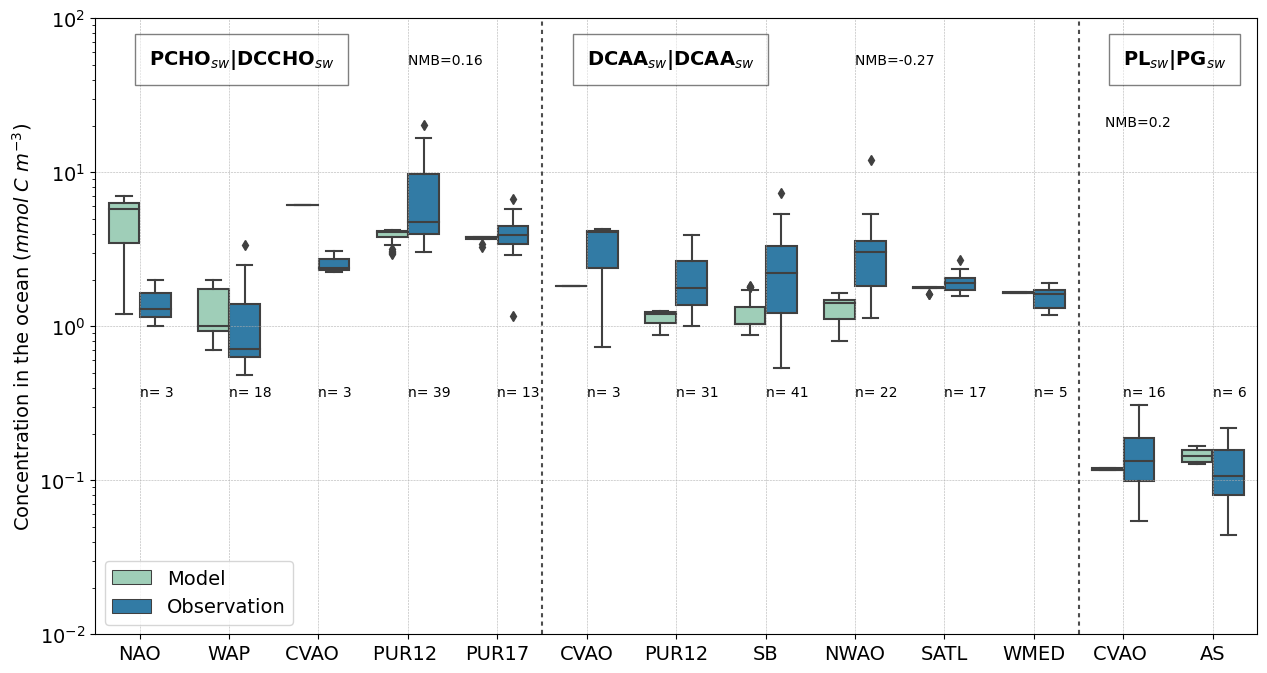

In [25]:
dict_df_all_groups = pd.concat([dict_df_po_test,dict_df_pr,dict_df_li_test])

box_plot_vert(dict_df_all_groups,
              [dict_pol_mod_obs,dict_pro_mod_obs,
               dict_lip_mod_obs],['pol','pro','lip'],
              'All_groups',[1e-2,1e2])



In [26]:
conc_name

'Concentration in the ocean ($mmol\\ C\\ m^{-3}$)'

In [ ]:
stations = {'pol  DCCHO [µMC]': ['NAO', 'WAP', 'CVAO', 'PUR12 ', 'PUR17'],
           'pro  DCAA [µMC]': ['PUR12', 'SB', 'NWAO', 'SATL', 'WMED'],
           'lip  PG': ['CVAO ', 'AS']}
c_na = 'Concentration in the ocean ($mmol\ C\ m^{-3}$)'

for idx, ID in enumerate(['pol  DCCHO [µMC]', 'pro  DCAA [µMC]','lip  PG']):
    
    print('\n',ID)
    dict_df_id = dict_df_all_groups[dict_df_all_groups['Macromolecules']==ID]
    
    for loc in stations[ID]:
        print(loc)
        dict_df_id_stat = dict_df_id[dict_df_id['Measurements'] == loc]
        stat_all = stat(dict_df_id_stat[dict_df_id_stat['']=='Model'][c_na],
                        dict_df_id_stat[dict_df_id_stat['']=='Observation'][c_na])

In [6]:
long3 = 358.2166667
long1 = (long3 + 180) % 360 - 180

In [7]:
long1

-1.7833332999999811